In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
data_set_path = [
    os.path.join(dirname, filename)
    for dirname, _, filenames in os.walk('/kaggle/input')
    for filename in filenames
]
[print(p) for p in data_set_path]

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

/kaggle/input/datasets/carlosr301101/high-order-neutron-transport/datos_N8.json
/kaggle/input/datasets/carlosr301101/high-order-neutron-transport/datos_N4.json
/kaggle/input/datasets/carlosr301101/high-order-neutron-transport/datos_N6.json


In [2]:
DATA_DIR = "/kaggle/input/datasets/carlosr301101/high-order-neutron-transport"

files = sorted(
    os.path.join(dirname, filename)
    for dirname, _, filenames in os.walk(DATA_DIR)
    for filename in filenames
    if filename.endswith(".json")
)
print(f"{len(files)} ficheros encontrados:")
print(*files, sep="\n")

3 ficheros encontrados:
/kaggle/input/datasets/carlosr301101/high-order-neutron-transport/datos_N4.json
/kaggle/input/datasets/carlosr301101/high-order-neutron-transport/datos_N6.json
/kaggle/input/datasets/carlosr301101/high-order-neutron-transport/datos_N8.json


In [3]:
rows = []
for path in files:
    with open(path, "r") as f:
        d = json.load(f)

    # orden de cuadratura: del campo JSON, si no, del nombre del fichero
    q = d.get("quadrature_order")
    if q is None:
        q = int("".join(c for c in os.path.basename(path) if c.isdigit()))

    for r in d["data"]:
        rows.append({
            "quad_order": int(q),
            "flux_0":     r["flux_0"],
            "flux_100":   r["flux_100"],
            "SCS":        r["SCS"],
        })

df = pd.DataFrame(rows)
print("Shape:", df.shape)
df

Shape: (54, 4)


,quad_order,flux_0,flux_100,SCS
0,4,0.846824,4.944409e-11,0.10
1,4,0.863025,6.675971e-11,0.15
2,4,0.880230,9.259641e-11,0.20
3,4,0.898562,1.324209e-10,0.25
4,4,0.918163,1.961063e-10,0.30
5,4,0.939208,3.023077e-10,0.35
6,4,0.961907,4.881107e-10,0.40
7,4,0.986521,8.316517e-10,0.45
8,4,1.013379,1.508924e-09,0.50
9,4,1.042902,2.948173e-09,0.55


In [4]:
print(df.dtypes, "\n")
print("NaNs:", df.isna().sum().sum())
print("\nSCS por orden de cuadratura:")
print(df.groupby("quad_order")["SCS"].describe())
print("\nRango flux_0:  ", df.flux_0.min(), "→", df.flux_0.max())
print("Rango flux_100:", df.flux_100.min(), "→", df.flux_100.max())

quad_order      int64
flux_0        float64
flux_100      float64
SCS           float64
dtype: object 

NaNs: 0

SCS por orden de cuadratura:
            count   mean       std  min     25%    50%     75%   max
quad_order                                                          
4            18.0  0.525  0.266927  0.1  0.3125  0.525  0.7375  0.95
6            18.0  0.525  0.266927  0.1  0.3125  0.525  0.7375  0.95
8            18.0  0.525  0.266927  0.1  0.3125  0.525  0.7375  0.95

Rango flux_0:   0.8195214141352064 → 1.5606050577232118
Rango flux_100: 4.94440867625379e-11 → 0.00032945512340204274


In [5]:
# ===========================
# CONFIGURACIÓN DEL EXPERIMENTO
# ===========================

MODEL_NAME = "MLP_Tanh_30x5"

ACTIVATION = "tanh"

LOSS_FUNCTION = "MSE"

LEARNING_RATE = 1e-3

EPOCHS = 5000

HIDDEN_LAYERS = [30,30,30,30,30]

OPTIMIZER = "Adam"

SEED = 42

# --- Early stopping ---
EARLY_STOPPING  = True
PATIENCE        = 300         # épocas sin mejora antes de parar
MIN_DELTA       = 1e-6        # mejora mínima para considerarla "mejora"

In [6]:
import os, time
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

XLSX_PATH     = "/kaggle/working/experimentos.xlsx"
SUMMARY_SHEET = "resumen"
PRED_SHEET    = "predicciones"

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    denom = np.where(y_true == 0, np.nan, y_true)     # MAPE robusto
    mape  = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape, r2

def build_results(train_loss, test_loss, mae, rmse, mape, r2, model, best_epoch=None):
    return {
        "Modelo":        MODEL_NAME,
        "Arquitectura":  str(HIDDEN_LAYERS),
        "Activacion":    ACTIVATION,
        "Loss":          LOSS_FUNCTION,
        "Optimizador":   OPTIMIZER,
        "Epochs":        EPOCHS,
        "Learning Rate": LEARNING_RATE,
        "Train Loss":    train_loss,
        "Test Loss":     test_loss,
        "MAE":           mae,
        "RMSE":          rmse,
        "MAPE":          mape,
        "R2":            r2,
        "Parametros":    sum(p.numel() for p in model.parameters()),
        "Best Epoch":    (best_epoch + 1) if best_epoch is not None else None,
    }

In [7]:
def append_experiment(results, preds_df=None, path=XLSX_PATH):
    row = dict(results)
    row["ID"]        = f"{results['Modelo']}_{time.strftime('%Y%m%d_%H%M%S')}"
    row["Timestamp"] = pd.Timestamp.now().isoformat(timespec="seconds")

    if os.path.exists(path):
        xls     = pd.ExcelFile(path)
        names   = xls.sheet_names
        summary = pd.read_excel(xls, sheet_name=SUMMARY_SHEET) if SUMMARY_SHEET in names else pd.DataFrame()
        old     = pd.read_excel(xls, sheet_name=PRED_SHEET)    if PRED_SHEET    in names else pd.DataFrame()
    else:
        summary, old = pd.DataFrame(), pd.DataFrame()

    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)

    all_pred = old
    if preds_df is not None:
        preds = preds_df.copy()
        preds.insert(0, "ID", row["ID"])
        preds.insert(1, "Modelo", results["Modelo"])
        all_pred = pd.concat([old, preds], ignore_index=True)

    with pd.ExcelWriter(path, engine="openpyxl") as w:
        summary.to_excel(w, sheet_name=SUMMARY_SHEET, index=False)
        all_pred.to_excel(w, sheet_name=PRED_SHEET,   index=False)

    print(f"Guardado en {path} | filas en resumen: {len(summary)}")
    return row["ID"]

## Applying One-Hot-Encode for Quad

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# X = [ one-hot(quad_order) (3) , flux_0 , flux_100 ]  ->  5 features
CAT_COLS = ["quad_order"]
NUM_COLS = ["flux_0", "flux_100"]

X_raw = df[CAT_COLS + NUM_COLS]
y = df["SCS"].to_numpy(dtype=np.float32).reshape(-1, 1)

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED
)

# one-hot SIN estandarizar; solo estandarizamos los flujos
preprocess = ColumnTransformer([
    ("quad_onehot", OneHotEncoder(categories=[[4, 6, 8]],
                                  sparse_output=False,
                                  handle_unknown="ignore"), CAT_COLS),
    ("flux_scale",  StandardScaler(), NUM_COLS),
])

X_tr = preprocess.fit_transform(X_tr_raw).astype(np.float32)
X_te = preprocess.transform(X_te_raw).astype(np.float32)

y_scaler = StandardScaler().fit(y_tr)
y_tr_s = y_scaler.transform(y_tr).astype(np.float32)
y_te_s = y_scaler.transform(y_te).astype(np.float32)

print("Features:", preprocess.get_feature_names_out())
print("X_tr:", X_tr.shape, " X_te:", X_te.shape)   # -> (43, 5)  (11, 5)

Features: ['quad_onehot__quad_order_4' 'quad_onehot__quad_order_6'
 'quad_onehot__quad_order_8' 'flux_scale__flux_0' 'flux_scale__flux_100']
X_tr: (43, 5)  X_te: (11, 5)


## Arch MLP

In [9]:
import torch
import torch.nn as nn

torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

class MLP(nn.Module):

    def __init__(self):
        super().__init__()
        layers = []
        input_size = 5                     # 3 one-hot + flux_0 + flux_100

        for neurons in HIDDEN_LAYERS:
            layers.append(nn.Linear(input_size, neurons))
            if ACTIVATION == "relu":
                layers.append(nn.ReLU())
            elif ACTIVATION == "tanh":
                layers.append(nn.Tanh())
            elif ACTIVATION == "elu":
                layers.append(nn.ELU())
            input_size = neurons

        layers.append(nn.Linear(input_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=30, bias=True)
    (7): Tanh()
    (8): Linear(in_features=30, out_features=30, bias=True)
    (9): Tanh()
    (10): Linear(in_features=30, out_features=1, bias=True)
  )
)


## Training

In [10]:
import copy

Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
yt = torch.tensor(y_tr_s, dtype=torch.float32, device=device)
Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
yv = torch.tensor(y_te_s, dtype=torch.float32, device=device)

loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val    = float("inf")
best_train  = float("inf")
best_state  = copy.deepcopy(model.state_dict())
best_epoch  = 0
no_improve  = 0
tr_hist, va_hist = [], []

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    optimizer.zero_grad()
    loss = loss_fn(model(Xt), yt)
    loss.backward()
    optimizer.step()

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val = loss_fn(model(Xv), yv).item()

    tr_hist.append(loss.item())
    va_hist.append(val)

    # --- early stopping ---
    if val < best_val - MIN_DELTA:
        best_val    = val
        best_train  = loss.item()
        best_state  = copy.deepcopy(model.state_dict())
        best_epoch  = epoch
        no_improve  = 0
    else:
        no_improve += 1

    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:5d}  train {loss.item():.3e}  "
              f"val {val:.3e}  best {best_val:.3e}  sin_mejora {no_improve}")

    if EARLY_STOPPING and no_improve >= PATIENCE:
        print(f"\n\u23f9 Early stopping en epoch {epoch+1} "
              f"(mejor epoch {best_epoch+1}, val={best_val:.3e})")
        break

# restauramos los MEJORES pesos, no los últimos
model.load_state_dict(best_state)

# compatible con build_results(train_history[-1], test_history[-1])
train_history, test_history = [best_train], [best_val]
print(f"\u2705 Mejor modelo restaurado: epoch {best_epoch+1}, "
      f"train={best_train:.3e}, val={best_val:.3e}")


epoch   100  train 1.650e-02  val 1.584e-02  best 1.549e-02  sin_mejora 13
epoch   200  train 4.165e-03  val 2.872e-03  best 2.872e-03  sin_mejora 0
epoch   300  train 1.397e-03  val 1.197e-03  best 1.197e-03  sin_mejora 0
epoch   400  train 5.059e-04  val 4.105e-04  best 4.105e-04  sin_mejora 0
epoch   500  train 2.370e-04  val 2.664e-04  best 2.672e-04  sin_mejora 5
epoch   600  train 1.640e-04  val 2.561e-04  best 2.563e-04  sin_mejora 1
epoch   700  train 1.233e-04  val 2.166e-04  best 2.176e-04  sin_mejora 2
epoch   800  train 9.104e-05  val 1.665e-04  best 1.670e-04  sin_mejora 1
epoch   900  train 6.544e-05  val 1.231e-04  best 1.239e-04  sin_mejora 2
epoch  1000  train 4.612e-05  val 9.122e-05  best 9.200e-05  sin_mejora 3
epoch  1100  train 3.235e-05  val 7.039e-05  best 7.120e-05  sin_mejora 5
epoch  1200  train 2.301e-05  val 5.817e-05  best 5.853e-05  sin_mejora 4
epoch  1300  train 1.695e-05  val 5.190e-05  best 5.232e-05  sin_mejora 10
epoch  1400  train 1.314e-05  val 4.

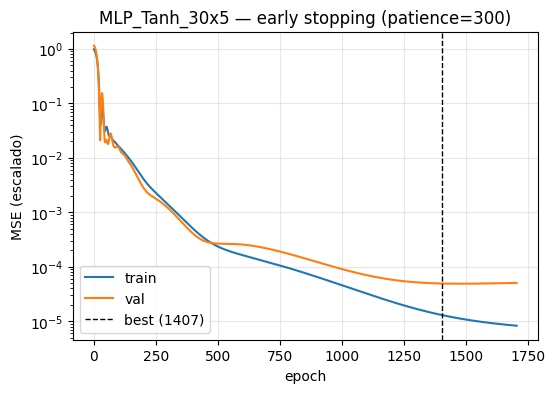

In [11]:
plt.figure(figsize=(6, 4))
plt.semilogy(tr_hist, label="train")
plt.semilogy(va_hist, label="val")
plt.axvline(best_epoch, color="k", ls="--", lw=1, label=f"best ({best_epoch+1})")
plt.xlabel("epoch"); plt.ylabel("MSE (escalado)")
plt.title(f"{MODEL_NAME} — early stopping (patience={PATIENCE})")
plt.legend(); plt.grid(alpha=.3); plt.show()

[train] MSE=8.411e-07  RMSE=9.171e-04  MAE=7.115e-04  R2=1.0000
[test] MSE=3.211e-06  RMSE=1.792e-03  MAE=1.138e-03  R2=1.0000


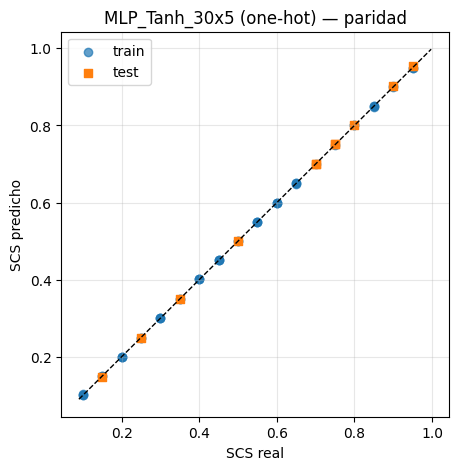

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    pred_tr = y_scaler.inverse_transform(model(Xt).cpu().numpy())
    pred_te = y_scaler.inverse_transform(model(Xv).cpu().numpy())
true_tr = y_scaler.inverse_transform(y_tr_s)
true_te = y_scaler.inverse_transform(y_te_s)

for name, t, p in [("train", true_tr, pred_tr), ("test", true_te, pred_te)]:
    print(f"[{name}] MSE={mean_squared_error(t, p):.3e}  "
          f"RMSE={mean_squared_error(t, p)**0.5:.3e}  "
          f"MAE={mean_absolute_error(t, p):.3e}  R2={r2_score(t, p):.4f}")

lo, hi = y.min()*0.9, y.max()*1.05
plt.figure(figsize=(5, 5))
plt.scatter(true_tr, pred_tr, label="train", alpha=.7)
plt.scatter(true_te, pred_te, label="test", marker="s")
plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel("SCS real"); plt.ylabel("SCS predicho")
plt.title(f"{MODEL_NAME} (one-hot) — paridad")
plt.legend(); plt.grid(alpha=.3); plt.show()

In [13]:
model.eval()
with torch.no_grad():
    pred_te = y_scaler.inverse_transform(model(Xv).cpu().numpy())
    pred_tr = y_scaler.inverse_transform(model(Xt).cpu().numpy())
true_te = y_scaler.inverse_transform(y_te_s)
true_tr = y_scaler.inverse_transform(y_tr_s)

mae, rmse, mape, r2 = compute_metrics(true_te, pred_te)

results = build_results(
    train_loss = train_history[-1],
    test_loss  = test_history[-1],
    mae=mae, rmse=rmse, mape=mape, r2=r2,
    model=model, best_epoch=best_epoch,
)

# predicciones (ambos splits) para la futura comparación por arquitectura
preds_df = pd.DataFrame({
    "split":      ["train"]*len(true_tr) + ["test"]*len(true_te),
    "quad_order": np.r_[X_tr_raw["quad_order"].values, X_te_raw["quad_order"].values],
    "flux_0":     np.r_[X_tr_raw["flux_0"].values,     X_te_raw["flux_0"].values],
    "flux_100":   np.r_[X_tr_raw["flux_100"].values,   X_te_raw["flux_100"].values],
    "SCS_true":   np.r_[true_tr.ravel(), true_te.ravel()],
    "SCS_pred":   np.r_[pred_tr.ravel(), pred_te.ravel()],
})

experiment_id = append_experiment(results, preds_df)
results_df = pd.DataFrame([results])
results_df

Guardado en /kaggle/working/experimentos.xlsx | filas en resumen: 1


,Modelo,Arquitectura,Activacion,Loss,Optimizador,Epochs,Learning Rate,Train Loss,Test Loss,MAE,RMSE,MAPE,R2,Parametros,Best Epoch
0,MLP_Tanh_30x5,"[30, 30, 30, 30, 30]",tanh,MSE,Adam,5000,0.001,0.000013,0.000049,0.001138,0.001792,0.239754,0.99995,3931,1407


In [14]:
import joblib, pandas as pd

joblib.dump({"model_state": model.state_dict(),
             "preprocess": preprocess, "y_scaler": y_scaler},
            f"{MODEL_NAME}_onehot.joblib")

def predict_sigma_s(quad_order, flux_0, flux_100):
    xr = pd.DataFrame([{"quad_order": quad_order,
                        "flux_0": flux_0, "flux_100": flux_100}])
    x = torch.tensor(preprocess.transform(xr).astype(np.float32), device=device)
    model.eval()
    with torch.no_grad():
        out = model(x).cpu().numpy()          # shape (1, 1)
    return float(y_scaler.inverse_transform(out)[0, 0])   # <-- [0, 0]

print("SCS predicho:", predict_sigma_s(6, 0.829531952377857, 1.246005020598936e-10))

SCS predicho: 0.10110997408628464


In [15]:
xls   = pd.ExcelFile(XLSX_PATH)
summ  = pd.read_excel(xls, sheet_name=SUMMARY_SHEET)
preds = pd.read_excel(xls, sheet_name=PRED_SHEET)

cols = ["R2", "RMSE", "MAE", "MAPE", "Parametros", "Best Epoch"]
summ.sort_values("R2", ascending=False)[["ID", "Modelo", "Arquitectura", "Activacion"] + cols]


,ID,Modelo,Arquitectura,Activacion,R2,RMSE,MAE,MAPE,Parametros,Best Epoch
0,MLP_Tanh_30x5_20260928_160605,MLP_Tanh_30x5,"[30, 30, 30, 30, 30]",tanh,0.99995,0.001792,0.001138,0.239754,3931,1407


### Predicciones de una arquitectura


                               ID         Modelo split  quad_order    flux_0  \
43  MLP_Tanh_30x5_20260928_160605  MLP_Tanh_30x5  test           6  0.845957   
44  MLP_Tanh_30x5_20260928_160605  MLP_Tanh_30x5  test           8  1.184218   
45  MLP_Tanh_30x5_20260928_160605  MLP_Tanh_30x5  test           8  1.134592   
46  MLP_Tanh_30x5_20260928_160605  MLP_Tanh_30x5  test           4  1.154111   
47  MLP_Tanh_30x5_20260928_160605  MLP_Tanh_30x5  test           8  0.990148   

        flux_100  SCS_true  SCS_pred  
43  1.549747e-10      0.15  0.148656  
44  1.317498e-07      0.75  0.750759  
45  4.264152e-08      0.70  0.700219  
46  4.027580e-08      0.70  0.700361  
47  1.996499e-09      0.50  0.500293  


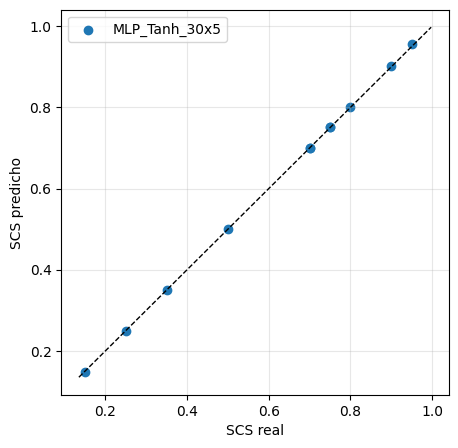

In [16]:
modelo = summ.sort_values("R2", ascending=False).iloc[0]["Modelo"]
sub = preds[(preds["Modelo"] == modelo) & (preds["split"] == "test")]
print(sub.head())

plt.figure(figsize=(5, 5))
plt.scatter(sub["SCS_true"], sub["SCS_pred"], label=modelo)
lo, hi = sub["SCS_true"].min()*0.9, sub["SCS_true"].max()*1.05
plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel("SCS real"); plt.ylabel("SCS predicho")
plt.legend(); plt.grid(alpha=.3)
plt.show()
